In [1]:
!pip install openpyxl -q

import pandas as pd
import ast                    # to parse the list-strings like "['Breast Cancer']"
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter


In [2]:
# Load the Excel file
df = pd.read_excel("SampleDateExtract.xlsx")

# First look — shape tells us rows × columns
print("Shape:", df.shape)

# Column names
print("\nColumns:")
for col in df.columns:
    print(" -", col)

Shape: (1000, 18)

Columns:
 - ID-datalake
 - nct_id
 - brief_title
 - official_title
 - phase
 - recruitment_status
 - start_date
 - completion_date
 - primary_completion_date
 - enrollment
 - enrollment_type
 - indications
 - interventions_drugs
 - drugs_datalake
 - main_technologies
 - specific_technologies
 - target_names
 - target_abbreviations


In [3]:
# dtypes tells us what pandas inferred for each column
print(df.dtypes)

ID-datalake                         int64
nct_id                             object
brief_title                        object
official_title                     object
phase                              object
recruitment_status                 object
start_date                 datetime64[ns]
completion_date            datetime64[ns]
primary_completion_date    datetime64[ns]
enrollment                        float64
enrollment_type                    object
indications                        object
interventions_drugs                object
drugs_datalake                     object
main_technologies                  object
specific_technologies              object
target_names                       object
target_abbreviations               object
dtype: object


In [4]:
# For each column, count nulls and compute completeness %
quality = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'completeness_%': ((1 - df.isnull().mean()) * 100).round(1)
})

# Sort so worst fields appear first
quality = quality.sort_values('completeness_%')

print(quality)

                         null_count  completeness_%
completion_date                  52            94.8
primary_completion_date          51            94.9
enrollment_type                  44            95.6
phase                            40            96.0
enrollment                       26            97.4
official_title                    6            99.4
start_date                        5            99.5
brief_title                       0           100.0
recruitment_status                0           100.0
ID-datalake                       0           100.0
nct_id                            0           100.0
indications                       0           100.0
interventions_drugs               0           100.0
drugs_datalake                    0           100.0
main_technologies                 0           100.0
specific_technologies             0           100.0
target_names                      0           100.0
target_abbreviations              0           100.0


In [5]:
# For fields that should have controlled vocabularies, check how many unique values exist
cat_cols = ['phase', 'recruitment_status', 'enrollment_type']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- phase ---
phase
PHASE2           402
PHASE1           253
PHASE1/PHASE2    126
PHASE3           124
NaN               40
PHASE4            25
PHASE2/PHASE3     17
EARLY_PHASE1      13
Name: count, dtype: int64

--- recruitment_status ---
recruitment_status
COMPLETED                  453
RECRUITING                 140
TERMINATED                 123
UNKNOWN                    121
ACTIVE_NOT_RECRUITING       76
NOT_YET_RECRUITING          41
WITHDRAWN                   40
SUSPENDED                    4
ENROLLING_BY_INVITATION      2
Name: count, dtype: int64

--- enrollment_type ---
enrollment_type
ACTUAL       598
ESTIMATED    358
NaN           44
Name: count, dtype: int64


In [6]:
# Check for duplicate trial IDs — would mean the same trial appears twice
print("Duplicate nct_id:", df['nct_id'].duplicated().sum())
print("Duplicate ID-datalake:", df['ID-datalake'].duplicated().sum())

Duplicate nct_id: 0
Duplicate ID-datalake: 0


In [7]:
# These 7 columns store Python lists as plain strings
# Let's look at what one actually looks like
list_cols = ['indications', 'interventions_drugs', 'drugs_datalake',
             'main_technologies', 'specific_technologies',
             'target_names', 'target_abbreviations']

print("Raw value in 'indications' for row 0:")
print(repr(df['indications'].iloc[0]))
print("\nType:", type(df['indications'].iloc[0]))

Raw value in 'indications' for row 0:
"['Anorectal Cancer', 'Epithelial Neoplasm']"

Type: <class 'str'>


In [8]:
# Look for mojibake (garbled encoding) in target fields
# Greek letters like α appear as garbage when encoding goes wrong
sample_targets = df['target_abbreviations'].dropna().head(20).tolist()
for t in sample_targets:
    if 'Î' in str(t) or 'â' in str(t):
        print("Encoding issue found:", t[:100])
        break
else:
    print("Check manually:")
    print(df['target_abbreviations'].iloc[4])

Encoding issue found: [['PD-1'], ['FGFR1', 'FGFR2', 'FGFR3', 'FGFR4', 'PDGFRÎ±', 'c-Kit', 'RET', 'VEGFR1', 'VEGFR2', 'VEGF


In [9]:
# Check for impossible date combos — completion before start
date_check = df.dropna(subset=['start_date', 'completion_date'])
bad_dates = date_check[date_check['completion_date'] < date_check['start_date']]
print("Trials where completion < start:", len(bad_dates))

# Also look at trial duration distribution
df['duration_days'] = (df['completion_date'] - df['start_date']).dt.days
print("\nDuration stats (days):")
print(df['duration_days'].describe().round(0))

Trials where completion < start: 0

Duration stats (days):
count      946.0
mean      1621.0
std       1142.0
min          0.0
25%        828.0
50%       1352.0
75%       2162.0
max      11137.0
Name: duration_days, dtype: float64


In [12]:
# This becomes a deliverable in your outputs/ folder
quality.to_csv("quality_report.csv")
print("Saved quality_report.csv")
print(quality)

Saved quality_report.csv
                         null_count  completeness_%
completion_date                  52            94.8
primary_completion_date          51            94.9
enrollment_type                  44            95.6
phase                            40            96.0
enrollment                       26            97.4
official_title                    6            99.4
start_date                        5            99.5
brief_title                       0           100.0
recruitment_status                0           100.0
ID-datalake                       0           100.0
nct_id                            0           100.0
indications                       0           100.0
interventions_drugs               0           100.0
drugs_datalake                    0           100.0
main_technologies                 0           100.0
specific_technologies             0           100.0
target_names                      0           100.0
target_abbreviations              0    

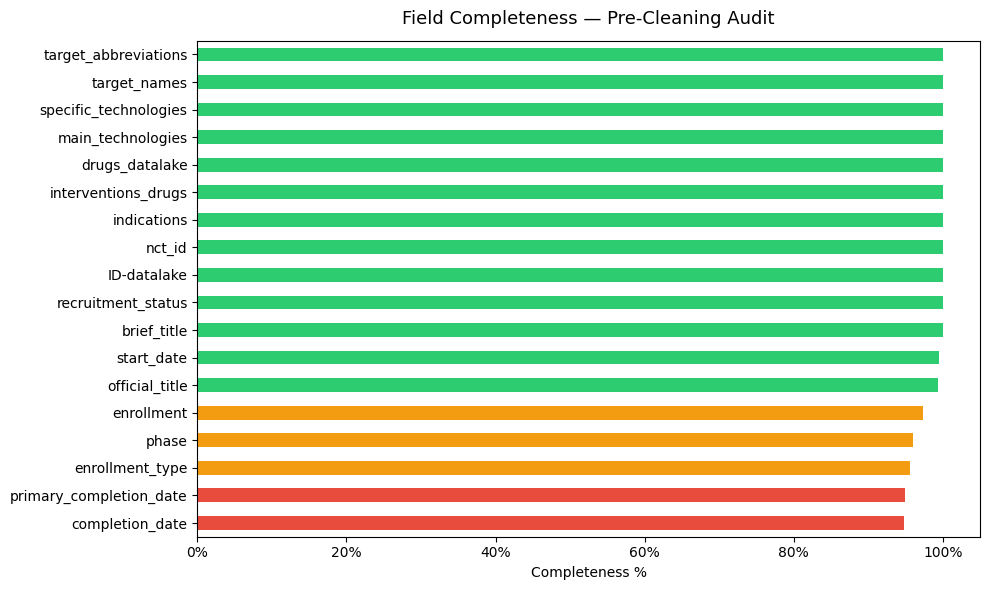

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if v < 95 else '#f39c12' if v < 99 else '#2ecc71'
          for v in quality['completeness_%']]

quality['completeness_%'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(100, color='white', linewidth=0.5, linestyle='--', alpha=0.3)
ax.set_xlabel("Completeness %")
ax.set_title("Field Completeness — Pre-Cleaning Audit", fontsize=13, pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig("completeness_report.png", dpi=150, bbox_inches='tight')
plt.show()

In [44]:
!find /content -name "*01*.ipynb"